# Chapter 1 — Tools of the Trade

### *Numerical Methods — from floating-point arithmetic to the Singular Value Decomposition*

This notebook reformats the lecture material of **Chapter 1** of the course *Metodi Numerici*
(lectures **L1–L7**: floating-point numbers, matrices and linear systems, norms, the condition
number, eigenvalues/eigenvectors, and the SVD) into a single, self-contained companion.

The goal is not only mathematical rigor, but also **visual intuition**: every abstract object
(a floating-point number, a matrix, a norm, an eigenvalue, a singular value) is something you can
*see* — as a point on a line, a deformed circle, an ellipse, a decaying curve, or an image. Building
that visual vocabulary is the real point of this chapter: it is the toolbox every later algorithm in
the course (Gauss elimination, iterative solvers, least squares, eigenvalue algorithms, ...) will
draw from.

> **Central thread.** Computer arithmetic is *not* the arithmetic of $\mathbb{R}$: it is finite,
> discrete, and non-associative. Chapter 1 builds the concepts needed to answer a single question
> that will recur in every chapter that follows: *given that our arithmetic is imperfect, how much
> can we trust the answer a computer gives us?* The **condition number** is the quantitative answer,
> and the **SVD** is the tool that makes it computable for *any* matrix.

## Roadmap

| # | Topic | Lecture(s) | Key object |
|---|-------|-----------|------------|
| 1 | Floating-point numbers | L1, L2 | machine epsilon $\varepsilon$ |
| 2 | Vectors, matrices, linear systems | L2, L3 | rank, kernel, range |
| 3 | Norms | L3, L4 | $\lVert \cdot \rVert_1,\lVert \cdot \rVert_2,\lVert \cdot \rVert_\infty$ |
| 4 | Condition number | L4, L5 | $K(A) = \lVert A\rVert\,\lVert A^{-1}\rVert$ |
| 5 | Eigenvalues & eigenvectors | L5 | $A = X\Lambda X^{-1}$, $A=Q\Lambda Q^T$ |
| 6 | Singular Value Decomposition | L6, L7 | $A = U\Sigma V^T = \sum_i \sigma_i u_i v_i^T$ |

Sections 1–6 mirror exactly the structure of the course's concept map and of
the *dispensa* "Metodi Numerici" by G. Puppo, Chapter 1: *Strumenti del mestiere*.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.figsize": (7, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})
COLORS = {
    "blue":   "#3B6EA8",
    "red":    "#C74A4A",
    "green":  "#4A9B6E",
    "orange": "#D98E3A",
    "purple": "#8E5FA8",
    "gray":   "#7A7A7A",
    "magenta":"#B84A8C",
}
print("Environment ready: numpy", np.__version__)


Environment ready: numpy 2.4.2


---
# 1. Floating-point numbers & the arithmetic of a finite machine

## 1.1 Why we must approximate

A computer has **finite memory**, so it can only store finitely many digits of any number. Integers
of bounded size are stored exactly; real numbers, in general, are not. Every real number typed into
a program is silently replaced by the nearest number the machine *can* represent — and everything
that follows in this course happens in that gap between $x \in \mathbb{R}$ and its machine
representation $\mathrm{fl}(x)$.

### Integers first (the easy case)

With $k$ bits of storage, the largest unsigned integer is $2^k - 1$. A signed 32-bit `int` reserves
one bit for the sign, so
$$ I_{\max} = 2^{31}-1 \approx 2.1\times 10^{9}. $$
A 64-bit `long int` reaches $I_{\max}=2^{63}-1\approx 9.2\times 10^{18}$. Push past $I_{\max}$ and you
get **integer overflow**: the value silently wraps around.


In [2]:

# Integer overflow is *not* a floating-point phenomenon: it happens because
# a fixed-width bit pattern simply cannot represent a bigger number.
for dtype in [np.int8, np.int32, np.int64]:
    info = np.iinfo(dtype)
    print(f"{dtype.__name__:>8s}: [{info.min:>22d}, {info.max:>22d}]")

print()
x = np.array([127], dtype=np.int8)   # int8 max is 127
print("127 (int8)      =", x[0])
with np.errstate(all="ignore"):
    y = x + np.int8(1)               # one past the maximum representable int8
print("127 + 1 (int8)  =", y[0], " <-- silently wrapped around to -128!")


    int8: [                  -128,                    127]
   int32: [           -2147483648,             2147483647]
   int64: [  -9223372036854775808,    9223372036854775807]

127 (int8)      = 127
127 + 1 (int8)  = -128  <-- silently wrapped around to -128!


## 1.2 Floating point: the normalized representation

Real numbers are stored as **floating point**, in normalized form
$$ x = \pm\, 0.a_1 a_2 \cdots a_t \; \beta^{q}, \qquad a_1 \neq 0, $$
where $\beta$ is the base ($\beta=2$ on a computer), $a_1 a_2 \cdots a_t$ is the **mantissa**
($t$ stored digits), and $q$ is the integer **exponent**. The set of all such numbers, for fixed
$(\beta, t, q_{\max})$, is denoted $\mathcal{F}(\beta, t, q_{\max})$ — a *finite* subset of
$\mathbb{R}$.

IEEE‑754 fixes the bit budget:

| type | total bits | sign | exponent | mantissa | $\varepsilon$ (machine epsilon) |
|---|---|---|---|---|---|
| `float32` (single) | 32 | 1 | 8 | 23 | $2^{-23}\approx 1.19\times10^{-7}$ |
| `float64` (double)  | 64 | 1 | 11 | 52 | $2^{-52}\approx 2.22\times10^{-16}$ |

The exponent range fixes overflow/underflow thresholds: for `float32`,
$x_{\max}\approx 2^{127}\approx 1.7\times10^{38}$; numbers larger than $x_{\max}$ become `Inf`
(**overflow**), numbers smaller than $x_{\min}\approx 2^{-127}$ in absolute value are flushed to
`0` (**underflow**).


In [3]:

for dt in [np.float32, np.float64]:
    info = np.finfo(dt)
    print(f"{dt.__name__:>8s}:  eps = {info.eps:.3e}   "
          f"max = {info.max:.3e}   tiny(min normal) = {info.tiny:.3e}")

print()
big = np.array([1e38], dtype=np.float32)
print("1e38  (float32)        =", big[0])
print("1e38 * 10 (float32)    =", (big * np.float32(10))[0], " <-- overflow -> inf")

small = np.array([1e-40], dtype=np.float32)
print("1e-40 (float32)        =", small[0], " <-- underflow -> 0.0")


 float32:  eps = 1.192e-07   max = 3.403e+38   tiny(min normal) = 1.175e-38
 float64:  eps = 2.220e-16   max = 1.798e+308   tiny(min normal) = 2.225e-308

1e38  (float32)        = 1e+38
1e38 * 10 (float32)    = inf  <-- overflow -> inf
1e-40 (float32)        = 1e-40  <-- underflow -> 0.0


C:\Users\user\AppData\Local\Temp\ipykernel_15452\2891637978.py:9: RuntimeWarning: overflow encountered in multiply
  print("1e38 * 10 (float32)    =", (big * np.float32(10))[0], " <-- overflow -> inf")


## 1.3 Rounding vs. truncation, and the birth of machine epsilon

To store a real $x = 0.a_1\cdots a_t a_{t+1}\cdots \,\beta^{q}$ in $\mathcal{F}$ we must discard the
digits beyond position $t$. Two strategies:

* **Truncation**: just drop them, $\tilde x = 0.a_1\cdots a_t\,\beta^q$.
* **Rounding**: keep the closest representable number.

$$ \underbrace{|x-\tilde x| \le \beta^{q-t}}_{\text{truncation}} \qquad\qquad
   \underbrace{|x-\tilde x| \le \tfrac12\beta^{q-t}}_{\text{rounding}} $$

Rounding *halves* the worst-case absolute error — always at least as good, never worse. The
**relative** error is more interesting: dividing by $|x|\ge 0.1\cdot\beta^q$, the exponent $q$
cancels out,
$$ \frac{|x-\tilde x|}{|x|} \;\le\; \tfrac12\,\beta^{1-t} \;=:\; \varepsilon. $$

This number $\varepsilon$ — the **machine epsilon** — is the single most important constant in
this chapter. It depends *only* on the precision $t$, never on the size of $x$. Equivalently,
$\varepsilon$ is the smallest floating-point number such that
$$ 1 + \varepsilon > 1 \quad\text{in floating-point arithmetic}. $$


In [4]:

def machine_epsilon(dtype):
    """Find eps empirically: the smallest eps with fl(1+eps) > 1."""
    one = dtype(1.0)
    eps = dtype(1.0)
    while dtype(one + eps / dtype(2.0)) > one:
        eps = dtype(eps / dtype(2.0))
    return eps

for dt in [np.float32, np.float64]:
    computed = machine_epsilon(dt)
    official = np.finfo(dt).eps
    print(f"{dt.__name__:>8s}:  empirical eps = {computed:.6e}   "
          f"np.finfo eps = {official:.6e}   match = {computed==official}")


 float32:  empirical eps = 1.192093e-07   np.finfo eps = 1.192093e-07   match = True
 float64:  empirical eps = 2.220446e-16   np.finfo eps = 2.220446e-16   match = True


## 1.4 Visual interlude: floating-point numbers are *not* uniformly spaced

This is the single most important picture in this section. Build a **toy** floating-point system
with $\beta=2$, a short mantissa $t=3$, and a small exponent range, then simply *enumerate every
number it can represent* and plot them on the real line.


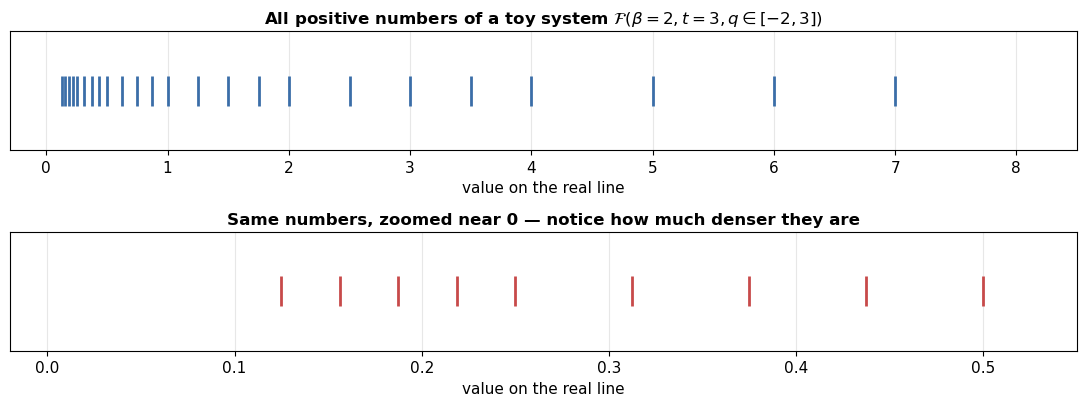

Smallest gap between consecutive floats: 0.03125
Largest gap between consecutive floats:  1.0
Ratio (largest/smallest):                32.0


In [5]:

def toy_float_system(beta=2, t=3, q_min=-2, q_max=3):
    """Enumerate all positive normalized floats in a toy system beta, t, [q_min, q_max]."""
    values = set()
    mantissa_digits_range = range(beta**(t-1), beta**t)  # a1 != 0
    for q in range(q_min, q_max + 1):
        for m in mantissa_digits_range:
            x = m * beta**(-t) * beta**q
            values.add(x)
    return np.array(sorted(values))

vals = toy_float_system(beta=2, t=3, q_min=-2, q_max=3)

fig, axes = plt.subplots(2, 1, figsize=(11, 4.2), height_ratios=[1, 1])

ax = axes[0]
ax.plot(vals, np.zeros_like(vals), "|", color=COLORS["blue"], markersize=22, mew=2)
ax.set_xlim(-0.3, 8.5)
ax.set_yticks([])
ax.set_title(r"All positive numbers of a toy system $\mathcal{F}(\beta{=}2, t{=}3, q\in[-2,3])$")
ax.set_xlabel("value on the real line")
ax.grid(axis="x", alpha=0.3)

ax = axes[1]
ax.plot(vals, np.zeros_like(vals), "|", color=COLORS["red"], markersize=22, mew=2)
ax.set_xlim(-0.02, 0.55)
ax.set_yticks([])
ax.set_title("Same numbers, zoomed near 0 — notice how much denser they are")
ax.set_xlabel("value on the real line")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

gaps = np.diff(vals)
print("Smallest gap between consecutive floats:", gaps.min())
print("Largest gap between consecutive floats: ", gaps.max())
print("Ratio (largest/smallest):               ", gaps.max()/gaps.min())


**Reading the picture.** Floating-point numbers are spaced *proportionally* to their own
magnitude: gaps double every time the exponent $q$ increases by one. Near $0$ they are packed
tightly; near $x_{\max}$ they are spread far apart. This is exactly what the error bounds above say
in geometric form: the *absolute* error $|x-\tilde x|\le \beta^{q-t}$ grows with $q$ (i.e. with the
gap size), while the *relative* error stays capped at $\varepsilon$ everywhere. **This non-uniform
spacing is the first sense in which computer arithmetic behaves nothing like $\mathbb{R}$.**


## 1.5 Floating-point operations: some are forgiving, some are not

Let $\hat x = x(1-\delta_x)$, $\hat y = y(1-\delta_y)$ be the floating-point representations of
$x,y$, with $|\delta_x|,|\delta_y|\le\varepsilon$. A short computation gives the relative error of a
**product**:
$$ \frac{|xy - \widehat{xy}|}{|xy|} \le |\delta_x+\delta_y-\delta_x\delta_y| \lesssim 3\varepsilon, $$
independent of the size of $x$ and $y$. Multiplication is **well-conditioned**.

For a **sum**,
$$ \frac{|(x+y) - (\hat x+\hat y)|}{|x+y|} = \frac{|x\delta_x + y\delta_y|}{|x+y|}. $$
If $x$ and $y$ have similar magnitude but opposite sign, $x+y\approx 0$ while the numerator stays
of order $\max(|x|,|y|)\,\varepsilon$ — the relative error **explodes**. This is
**catastrophic cancellation**: subtracting two nearly-equal numbers destroys significant digits.


In [6]:

# ---- Well-conditioned: product -----------------------------------------
rng = np.random.default_rng(0)
x64, y64 = 1.234567891234567, 9.876543219876543
xf, yf = np.float32(x64), np.float32(y64)
exact = x64 * y64
approx = float(xf) * float(yf)
print("Product   -- relative error:", abs(exact-approx)/abs(exact), "  (~ a few * eps_float32 =", 3*np.finfo(np.float32).eps, ")")

# ---- Catastrophic cancellation: sum of nearly opposite numbers --------
a64, b64 = 1.0000000123456789, -1.0000000000000002
af, bf = np.float32(a64), np.float32(b64)
exact_sum = a64 + b64
approx_sum = float(af) + float(bf)
rel_err = abs(exact_sum - approx_sum) / abs(exact_sum)
print("Cancellation -- x+y (exact, float64):", exact_sum)
print("Cancellation -- x+y (float32):       ", approx_sum)
print("Cancellation -- relative error:       %.3e  <-- catastrophically larger than eps!" % rel_err)


Product   -- relative error: 2.6291100219587054e-08   (~ a few * eps_float32 = 3.5762787e-07 )
Cancellation -- x+y (exact, float64): 1.2345678701564111e-08
Cancellation -- x+y (float32):        0.0
Cancellation -- relative error:       1.000e+00  <-- catastrophically larger than eps!


### A classic victim: the quadratic formula

For $ax^2+bx+c=0$ the textbook formula is
$$ x_{1,2} = \frac{-b \pm \sqrt{b^2-4ac}}{2a}. $$
When $b^2 \gg 4ac$ (i.e. $\sqrt{b^2-4ac}\approx |b|$), **one** of the two roots is computed as a
difference of nearly-equal numbers — catastrophic cancellation. The fix uses the identity
$x_1 x_2 = c/a$ to compute the *safe* root directly and the *dangerous* one from the product:
$$ x_1 = \frac{-b-\mathrm{sign}(b)\sqrt{b^2-4ac}}{2a}, \qquad x_2 = \frac{c}{a\,x_1}. $$


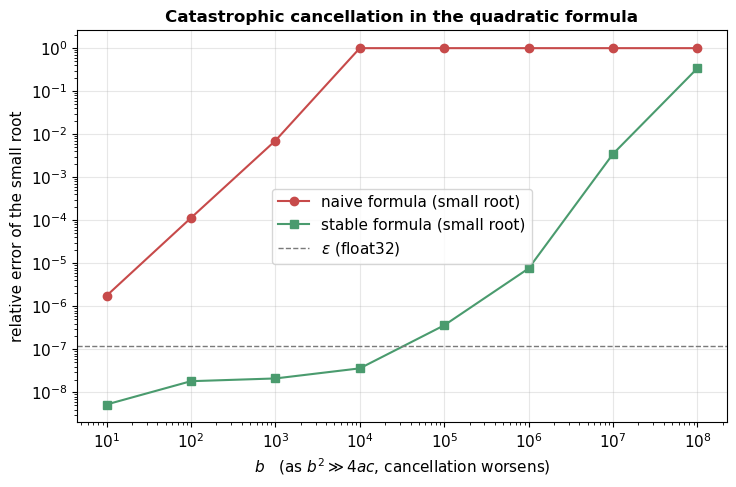

In [7]:

def quadratic_naive(a, b, c):
    disc = np.sqrt(b**2 - 4*a*c)
    return (-b + disc) / (2*a), (-b - disc) / (2*a)

def quadratic_stable(a, b, c):
    disc = np.sqrt(b**2 - 4*a*c)
    x1 = (-b - np.sign(b) * disc) / (2*a)
    x2 = c / (a * x1)
    return x1, x2

# ill-conditioned regime: b^2 >> 4ac
# "Ground truth": float64 is ~1e9x more precise than float32 (eps64/eps32 ~ 2e-9),
# so it is an excellent reference against which to measure float32 errors below.
def exact_roots(a, b, c):
    a_, b_, c_ = np.float64(a), np.float64(b), np.float64(c)
    disc = np.sqrt(b_**2 - 4*a_*c_)
    return [(-b_ + disc) / (2*a_), (-b_ - disc) / (2*a_)]

a, c = 1.0, 1.0
b_values = np.array([1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8], dtype=np.float64)
err_naive, err_stable = [], []

for b in b_values:
    ref = exact_roots(a, b, c)
    ref_small = min(ref, key=lambda z: abs(z))  # the "small", cancellation-prone root

    xn1, xn2 = quadratic_naive(np.float32(a), np.float32(b), np.float32(c))
    xs1, xs2 = quadratic_stable(np.float32(a), np.float32(b), np.float32(c))

    naive_small  = min([xn1, xn2], key=lambda z: abs(z))
    stable_small = min([xs1, xs2], key=lambda z: abs(z))

    err_naive.append(abs(float(naive_small) - float(ref_small)) / abs(float(ref_small)))
    err_stable.append(abs(float(stable_small) - float(ref_small)) / abs(float(ref_small)))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(b_values, err_naive, "o-", color=COLORS["red"], label="naive formula (small root)")
ax.loglog(b_values, err_stable, "s-", color=COLORS["green"], label="stable formula (small root)")
ax.axhline(np.finfo(np.float32).eps, color=COLORS["gray"], ls="--", lw=1, label=r"$\varepsilon$ (float32)")
ax.set_xlabel(r"$b$   (as $b^2 \gg 4ac$, cancellation worsens)")
ax.set_ylabel("relative error of the small root")
ax.set_title("Catastrophic cancellation in the quadratic formula")
ax.legend()
plt.tight_layout()
plt.show()


The naive formula's error grows *linearly* with $b$ — every extra order of magnitude in $b$
costs a full digit of accuracy in the small root. The algebraically-equivalent stable formula stays
pinned at the machine-epsilon floor throughout. **Same mathematics, same final answer in exact
arithmetic — wildly different behavior in floating point.** This is the essence of numerical
*stability*: how you compute matters as much as what you compute.


## 1.6 A finite-difference bonus: the U-shaped error curve

One more place cancellation lurks: numerical differentiation, $f'(x_0)\approx \dfrac{f(x_0+h)-f(x_0)}{h}$.
Truncation error shrinks like $O(h)$ as $h\to 0$ — so smaller $h$ should be *better* — but the
numerator is a subtraction of two nearly-equal floating-point numbers, so **rounding** error grows
like $O(\varepsilon/h)$. The total error is the sum of both, and it is minimized at an intermediate,
non-zero $h^\star \sim \sqrt{\varepsilon}$.


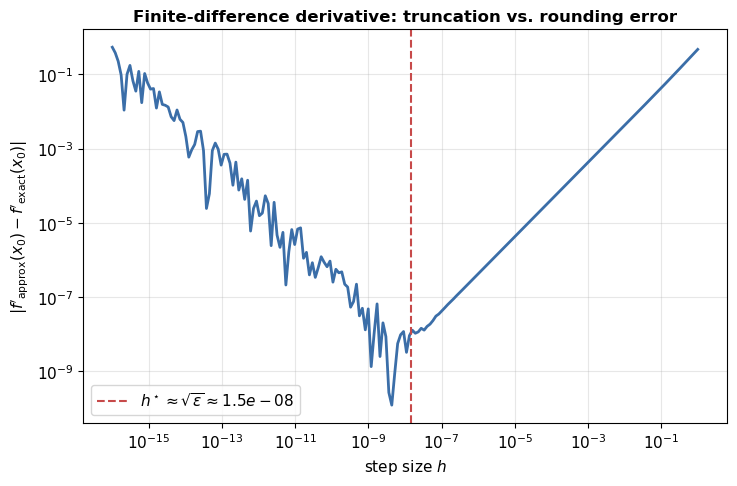

Optimal h (empirical minimum):  4.347e-09
Optimal h (theory, sqrt(eps)):  1.490e-08


In [8]:

f = np.sin
fprime_exact = np.cos
x0 = 1.0

h_values = np.logspace(-16, 0, 200)
errors = []
for h in h_values:
    approx = (f(x0 + h) - f(x0)) / h
    errors.append(abs(approx - fprime_exact(x0)))
errors = np.array(errors)

h_star = np.sqrt(np.finfo(np.float64).eps)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(h_values, errors, color=COLORS["blue"], lw=2)
ax.axvline(h_star, color=COLORS["red"], ls="--", lw=1.5,
           label=r"$h^\star \approx \sqrt{\varepsilon} \approx %.1e$" % h_star)
ax.set_xlabel(r"step size $h$")
ax.set_ylabel(r"$|f'_{\rm approx}(x_0) - f'_{\rm exact}(x_0)|$")
ax.set_title("Finite-difference derivative: truncation vs. rounding error")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Optimal h (empirical minimum):  {h_values[np.argmin(errors)]:.3e}")
print(f"Optimal h (theory, sqrt(eps)):  {h_star:.3e}")


Left of the minimum, rounding error (cancellation in the numerator) dominates and *grows* as
$h$ shrinks; right of the minimum, truncation error dominates. **Making $h$ smaller is not always
better** — a fact with no analogue in ordinary calculus, where you are always free to take
$h\to 0$.


## 1.7 Floating point is not a field: associativity fails

In $\mathbb{R}$, $(a+b)+c = a+(b+c)$ always. In $\mathcal{F}$, each `+` rounds its result, and the
two evaluation orders can round differently.


In [9]:

a = np.float32(1.0)
b = np.float32(1e8)
c = np.float32(-1e8)

left  = (a + b) + c
right = a + (b + c)

print("a, b, c =", a, b, c)
print("(a + b) + c =", left)
print("a + (b + c) =", right)
print("Equal?", left == right, " <-- order of operations changes the result!")


a, b, c = 1.0 1e+08 -1e+08
(a + b) + c = 0.0
a + (b + c) = 1.0
Equal? False  <-- order of operations changes the result!


**Takeaway of Section 1.** Floating-point arithmetic is finite, non-uniformly spaced, and
non-associative. Multiplication and division are forgiving (errors of order $\varepsilon$ regardless
of the operands); addition/subtraction of nearby quantities is not. Every algorithm in the rest of
this course must be judged not only by *what it computes* but by *how it computes it* — the
question Sections 4–6 will make precise through the **condition number**.


---
# 2. Vectors, matrices, and linear systems

## 2.1 Vectors: objects vs. coordinates

A vector $x \in \mathbb{R}^n$ is written as a column, $x=[x_1,\dots,x_n]^T$. It is essential to keep
apart the **vector** $x$ (a geometric object) from its **coordinates** $x_i$, which are only
meaningful once a basis is fixed. In the canonical basis $\{e_1,\dots,e_n\}$,
$$ x = x_1 e_1 + x_2 e_2 + \cdots + x_n e_n. $$
Change the basis and the coordinates change — but $x$ itself does not.

The inner product $(x,y)=x^Ty=\sum_i x_i y_i$ costs $O(n)$ operations; two vectors are
**orthogonal** if $(x,y)=0$.

## 2.2 A matrix *is* a linear map — and $Ax$ is a combination of columns

For $A \in \mathbb{R}^{m\times n}$ with columns $a_1,\dots,a_n \in \mathbb{R}^m$,
$$ Ax = x_1 a_1 + x_2 a_2 + \cdots + x_n a_n. $$
This single identity is the geometric key to everything that follows: **the image of $x$ under $A$
is nothing but a weighted sum of the columns of $A$**, with weights given by the entries of $x$.


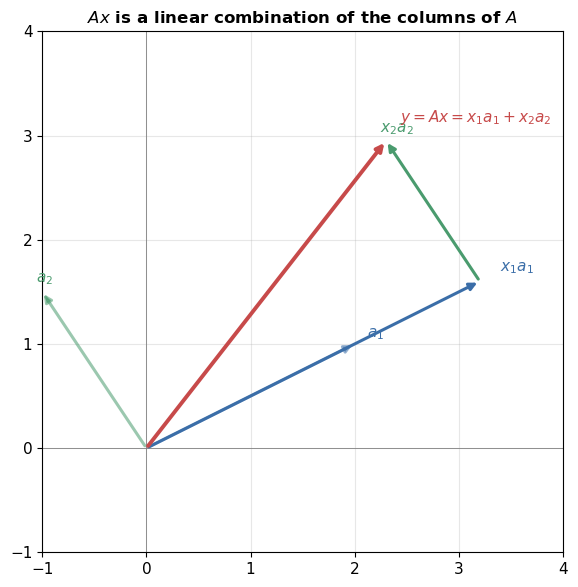

A @ x = [2.3  2.95]    x1*a1 + x2*a2 = [2.3  2.95]


In [10]:

A = np.array([[2.0, -1.0],
              [1.0,  1.5]])
x = np.array([1.6, 0.9])

a1, a2 = A[:, 0], A[:, 1]
y = A @ x

fig, ax = plt.subplots(figsize=(6.5, 6))
origin = np.zeros(2)

def arrow(ax, vec, color, label, start=None, alpha=1.0, lw=2.2):
    start = origin if start is None else start
    ax.annotate("", xy=start+vec, xytext=start,
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, alpha=alpha))
    ax.text(*(start + vec*1.06), label, color=color, fontsize=11, fontweight="bold")

arrow(ax, a1, COLORS["blue"],   r"$a_1$", alpha=0.55)
arrow(ax, a2, COLORS["green"],  r"$a_2$", alpha=0.55)
arrow(ax, x1a1 := x[0]*a1, COLORS["blue"],  r"$x_1 a_1$")
arrow(ax, x2a2 := x[1]*a2, COLORS["green"], r"$x_2 a_2$", start=x1a1)
arrow(ax, y, COLORS["red"], r"$y = Ax = x_1a_1+x_2a_2$", lw=2.8)

ax.set_xlim(-1, 4); ax.set_ylim(-1, 4)
ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
ax.set_aspect("equal")
ax.set_title(r"$Ax$ is a linear combination of the columns of $A$")
plt.tight_layout()
plt.show()
print("A @ x =", y, "   x1*a1 + x2*a2 =", x1a1 + x2a2)


## 2.3 Rank, kernel, range — and how many solutions $Ax=b$ has

* **Rank**: $\mathrm{rank}(A)$ = number of linearly independent columns = $\dim(\mathrm{range}(A))$.
* **Kernel**: $\ker(A) = \{x : Ax = 0\}$ (always contains $0$).
* **Range**: $\mathrm{range}(A) = \mathrm{span}(a_1,\dots,a_n)$.

Solving $Ax=b$ means finding the combination of columns of $A$ that produces $b$ — i.e. asking
whether $b\in\mathrm{range}(A)$.

| shape | name | typical outcome |
|---|---|---|
| $m=n$, full rank | square, invertible | **unique** solution $x=A^{-1}b$ |
| $m=n$, rank $<n$ | square, singular | none, or infinitely many |
| $m>n$ | **over-determined** | generally *no exact solution*; minimize the residual $r=Ax-b$ |
| $m<n$ | **under-determined** | infinitely many solutions; pick the one of minimal norm |


In [11]:

def classify_system(A, b, tol=1e-10):
    m, n = A.shape
    rank = np.linalg.matrix_rank(A, tol=tol)
    aug_rank = np.linalg.matrix_rank(np.column_stack([A, b]), tol=tol)
    if m == n and rank == n:
        kind = "square, full rank -> unique solution"
    elif rank < min(m, n):
        kind = "rank-deficient"
    elif m > n:
        kind = "over-determined (likely no exact solution; least squares)"
    else:
        kind = "under-determined (infinitely many solutions; minimum-norm)"
    solvable = (aug_rank == rank)
    return kind, rank, solvable

cases = {
    "square, full rank":   (np.array([[2.,1.],[1.,3.]]),           np.array([1., 2.])),
    "over-determined":     (np.array([[1.,0.],[0.,1.],[1.,1.]]),   np.array([1., 1., 1.])),
    "under-determined":    (np.array([[1., 2., 3.]]),              np.array([6.])),
}
for name, (A, b) in cases.items():
    kind, rank, solvable = classify_system(A, b)
    print(f"{name:22s}: A is {A.shape},  rank={rank},  b in range(A)? {solvable}  ->  {kind}")


square, full rank     : A is (2, 2),  rank=2,  b in range(A)? True  ->  square, full rank -> unique solution
over-determined       : A is (3, 2),  rank=2,  b in range(A)? False  ->  over-determined (likely no exact solution; least squares)
under-determined      : A is (1, 3),  rank=1,  b in range(A)? True  ->  under-determined (infinitely many solutions; minimum-norm)


## 2.4 Special matrices

* **Symmetric**: $A=A^T$.
* **Orthogonal**: $Q^{-1}=Q^T$, i.e. $Q^TQ=I$ — columns are orthonormal. Orthogonal matrices are
  exactly the linear maps that **preserve length**: $\lVert Qx\rVert_2 = \lVert x \rVert_2$.
* **Rank-1**: $A = a\,c^T$ (an **outer product**) — every column is a multiple of $a$. This is the
  atomic building block the SVD will use in Section 6.
* **Diagonal**: right-multiplication by $D$ rescales *columns*; left-multiplication rescales *rows*.


Q^T Q  =
 [[1. 0.]
 [0. 1.]]  (should be I: Q is orthogonal)
det(Q) = 1.0  (a rotation: det = +1)

Rank-1 matrix  a c^T =
 [[ 2.   6. ]
 [-1.  -3. ]
 [ 0.5  1.5]]
rank(a c^T) = 1  <- always 1, for any nonzero a, c


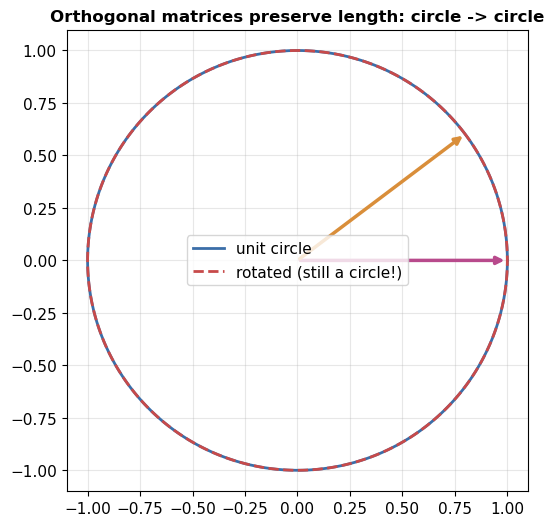

In [12]:

theta = np.deg2rad(37)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print("Q^T Q  =\n", Q.T @ Q, " (should be I: Q is orthogonal)")
print("det(Q) =", np.linalg.det(Q), " (a rotation: det = +1)")

# A rank-1 matrix as an outer product
a = np.array([2.0, -1.0, 0.5])
c = np.array([1.0, 3.0])
R1 = np.outer(a, c)
print("\nRank-1 matrix  a c^T =\n", R1)
print("rank(a c^T) =", np.linalg.matrix_rank(R1), " <- always 1, for any nonzero a, c")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
circ = np.array([np.cos(np.linspace(0, 2*np.pi, 200)), np.sin(np.linspace(0, 2*np.pi, 200))])
ax.plot(*circ, color=COLORS["blue"], lw=2, label="unit circle")
ax.plot(*(Q @ circ), color=COLORS["red"], lw=2, ls="--", label="rotated (still a circle!)")
for v, col in [(np.array([1, 0]), COLORS["magenta"]), (Q@np.array([1, 0]), COLORS["orange"])]:
    ax.annotate("", xy=v, xytext=(0,0), arrowprops=dict(arrowstyle="-|>", color=col, lw=2.5))
ax.set_aspect("equal"); ax.legend(); ax.set_title("Orthogonal matrices preserve length: circle -> circle")
plt.tight_layout()
plt.show()


## 2.5 Preview: how *does* a generic matrix act on the unit circle?

A rotation leaves the unit circle a circle. What about a generic matrix? This is the picture that
will motivate the entire second half of this notebook (eigenvalues in Section 5, SVD in Section 6):
a generic linear map deforms the unit circle into an **ellipse**.


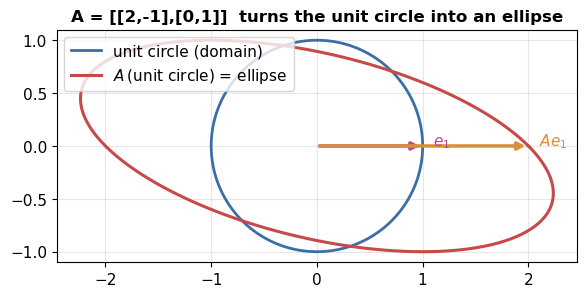

In [13]:

def unit_circle(n=300):
    t = np.linspace(0, 2*np.pi, n)
    return np.vstack([np.cos(t), np.sin(t)])

A_demo = np.array([[2.0, -1.0],
                    [0.0,  1.0]])
circ = unit_circle()
img = A_demo @ circ
e1 = np.array([1.0, 0.0])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(*circ, color=COLORS["blue"], lw=2, label="unit circle (domain)")
ax.plot(*img, color=COLORS["red"], lw=2.2, label=r"$A\,($unit circle$)$ = ellipse")
ax.annotate("", xy=e1, xytext=(0,0), arrowprops=dict(arrowstyle="-|>", color=COLORS["magenta"], lw=2.5))
ax.annotate("", xy=A_demo@e1, xytext=(0,0), arrowprops=dict(arrowstyle="-|>", color=COLORS["orange"], lw=2.5))
ax.text(*(e1*1.1), r"$e_1$", color=COLORS["magenta"], fontweight="bold")
ax.text(*(A_demo@e1*1.05), r"$Ae_1$", color=COLORS["orange"], fontweight="bold")
ax.set_aspect("equal"); ax.legend(loc="upper left")
ax.set_title("A = [[2,-1],[0,1]]  turns the unit circle into an ellipse")
plt.tight_layout()
plt.show()


We will come back to this exact picture twice: once with **eigenvectors** (Section 5 — which,
we will see, do *not* always give the axes of this ellipse), and once with **singular vectors**
(Section 6 — which always do, for *every* matrix, symmetric or not, square or not).


---
# 3. Norms: measuring the size of a vector, and of an error

If we solve $Ax=b$ numerically, the computed $\tilde x$ is never exactly $x$. To even *talk about*
the error $x-\tilde x \in \mathbb{R}^n$, we need a single number summarizing "how big" a vector is —
a **norm**.

## 3.1 Vector norms

A norm $\lVert\cdot\rVert : \mathbb{R}^n \to \mathbb{R}^+$ must satisfy
$$ \lVert x\rVert \ge 0,\ \ \lVert x\rVert=0 \iff x=0, \qquad
   \lVert \alpha x\rVert = |\alpha|\,\lVert x\rVert, \qquad
   \lVert x+y\rVert \le \lVert x\rVert + \lVert y\rVert\ \ (\text{triangle inequality}). $$

The $p$-norm family, $\lVert x \rVert_p = \big(\sum_i |x_i|^p\big)^{1/p}$, gives the three we will use
constantly:
$$ \lVert x\rVert_1=\sum_i|x_i|, \qquad
   \lVert x\rVert_2=\sqrt{\textstyle\sum_i x_i^2}, \qquad
   \lVert x\rVert_\infty=\max_i|x_i|. $$

### Visual interlude: unit balls

The shape of $\{x : \lVert x\rVert_p = 1\}$ is *not* a circle except for $p=2$.


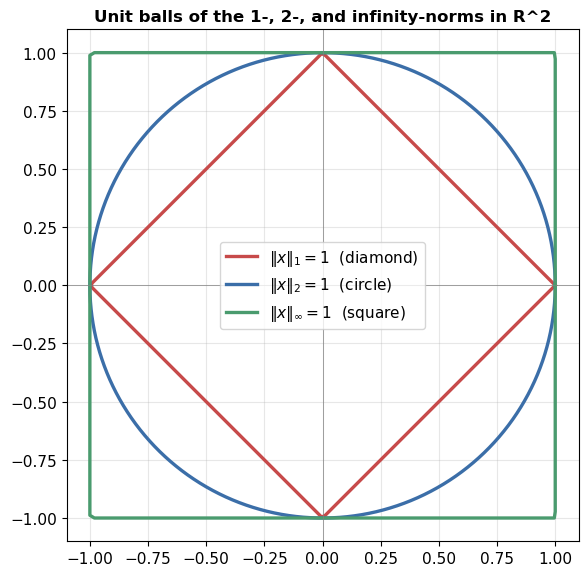

In [14]:

theta = np.linspace(0, 2*np.pi, 400)
circle2 = np.array([np.cos(theta), np.sin(theta)])                 # ||x||_2 = 1
diamond1 = np.array([np.cos(theta), np.sin(theta)])
diamond1 = diamond1 / np.abs(diamond1).sum(axis=0)                  # ||x||_1 = 1
square_inf = np.array([np.cos(theta), np.sin(theta)])
square_inf = square_inf / np.abs(square_inf).max(axis=0)            # ||x||_inf = 1

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(*diamond1,   color=COLORS["red"],    lw=2.4, label=r"$\|x\|_1=1$  (diamond)")
ax.plot(*circle2,    color=COLORS["blue"],   lw=2.4, label=r"$\|x\|_2=1$  (circle)")
ax.plot(*square_inf, color=COLORS["green"],  lw=2.4, label=r"$\|x\|_\infty=1$  (square)")
ax.set_aspect("equal"); ax.legend(); ax.set_title("Unit balls of the 1-, 2-, and infinity-norms in R^2")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
plt.tight_layout()
plt.show()


All $p$-norms are **equivalent** on $\mathbb{R}^n$ (finite dimension): there exist constants
$0<c_1<c_2$ with $c_1\lVert x\rVert_p \le \lVert x\rVert_q \le c_2\lVert x\rVert_p$. So convergence in
one norm implies convergence in all of them — but the constants can depend badly on $n$, as we will
see with the Hilbert matrix in Section 4.

## 3.2 Matrix norms: two philosophies

**(a) Treat $A$ as a long vector** — the Frobenius norm,
$\lVert A\rVert_F = \big(\sum_{i,j}|a_{ij}|^2\big)^{1/2}$.

**(b) Treat $A$ as an operator** — the **induced** norm, measuring the largest possible
*stretch factor*:
$$ \lVert A \rVert_p = \sup_{x\neq 0} \frac{\lVert Ax\rVert_p}{\lVert x\rVert_p}
                      = \sup_{\lVert x\rVert_p=1} \lVert Ax\rVert_p. $$
By construction, $\lVert Ax\rVert_p \le \lVert A\rVert_p\,\lVert x\rVert_p$ for every $x$ — the
inequality that will drive the condition-number bound in Section 4.

Two induced norms have closed-form, $O(n^2)$ formulas — no optimization needed:
$$ \lVert A\rVert_1 = \max_j \sum_i |a_{ij}| \ \text{(max column sum)}, \qquad
   \lVert A\rVert_\infty = \max_i \sum_j |a_{ij}| \ \text{(max row sum)}. $$
($\lVert A\rVert_2$, the max *stretch* in Euclidean norm, needs the SVD — Section 6.)


In [15]:

rng = np.random.default_rng(1)
A = rng.normal(size=(5, 5))

norm1_formula = np.max(np.abs(A).sum(axis=0))     # max column sum
norminf_formula = np.max(np.abs(A).sum(axis=1))   # max row sum

# brute-force / Monte Carlo cross-check: sample many unit-norm x and maximize ||Ax||_p / ||x||_p
def brute_force_induced_norm(A, p, n_samples=200_000, seed=0):
    rng = np.random.default_rng(seed)
    n = A.shape[1]
    X = rng.normal(size=(n_samples, n))
    X /= np.linalg.norm(X, ord=p, axis=1, keepdims=True)
    ratios = np.linalg.norm(X @ A.T, ord=p, axis=1)
    return ratios.max()

bf1 = brute_force_induced_norm(A, 1)
bfinf = brute_force_induced_norm(A, np.inf)

print(f"||A||_1    formula = {norm1_formula:.6f}    Monte-Carlo estimate = {bf1:.6f}")
print(f"||A||_inf  formula = {norminf_formula:.6f}    Monte-Carlo estimate = {bfinf:.6f}")
print(f"||A||_F            = {np.linalg.norm(A, 'fro'):.6f}   (numpy) vs "
      f"{np.sqrt((A**2).sum()):.6f} (by hand)")
print("\n(numpy.linalg.norm agrees:  ||A||_1 =", np.linalg.norm(A, 1),
      "   ||A||_inf =", np.linalg.norm(A, np.inf), ")")


||A||_1    formula = 4.649962    Monte-Carlo estimate = 4.346745
||A||_inf  formula = 5.295696    Monte-Carlo estimate = 5.171494
||A||_F            = 4.099400   (numpy) vs 4.099400 (by hand)

(numpy.linalg.norm agrees:  ||A||_1 = 4.6499623955934615    ||A||_inf = 5.295695694487684 )


**Why we need this.** If $\tilde x$ solves a *perturbed* problem $A\tilde x = \tilde b$ instead
of the true $Ax=b$, the error obeys
$$ \lVert x-\tilde x\rVert = \lVert A^{-1}(b-\tilde b)\rVert \le \lVert A^{-1}\rVert\,\lVert b-\tilde b\rVert. $$
The matrix norm $\lVert A^{-1}\rVert$ is exactly the amplification factor between an error in the
data $b$ and an error in the solution $x$. Section 4 turns this single inequality into the
**condition number**.


---
# 4. The condition number — when small errors become big problems

## 4.1 Definition

Suppose we want to solve $Ax=b$, but the data we actually have is a slightly perturbed
$\tilde b$, so we really solve $A\tilde x=\tilde b$. Chaining the two facts
$\lVert x-\tilde x\rVert \le \lVert A^{-1}\rVert\,\lVert b-\tilde b\rVert$ (Section 3) and
$1/\lVert x\rVert \le \lVert A\rVert / \lVert b\rVert$ (since $\lVert b\rVert=\lVert Ax\rVert\le
\lVert A\rVert\lVert x\rVert$) gives the **relative** error bound
$$ \frac{\lVert x - \tilde x\rVert}{\lVert x\rVert} \;\le\;
   \underbrace{\lVert A\rVert\,\lVert A^{-1}\rVert}_{\displaystyle K(A)} \;
   \frac{\lVert b - \tilde b\rVert}{\lVert b\rVert}. $$

$K(A)$, the **condition number**, tells us the *worst-case* amplification of a relative error in the
data into a relative error in the solution. Crucially, **$K(A)$ depends only on the matrix $A$ — not
on which algorithm we use to solve $Ax=b$.** A well-conditioned problem forgives sloppy algorithms;
an ill-conditioned one punishes even the best ones.

## 4.2 Basic properties

* $K(A) \ge 1$ always: $1 = \lVert I\rVert = \lVert A^{-1}A\rVert \le \lVert A^{-1}\rVert\lVert A\rVert$.
* $K(I) = 1$ (the best possible case).
* $K(Q) = 1$ for any **orthogonal** matrix $Q$ — since $\lVert Q\rVert_2 = \lVert Q^{-1}\rVert_2 = 1$.
  Orthogonal transformations are *perfectly* conditioned: they never amplify error. This is exactly
  why numerical linear algebra tries so hard to build algorithms out of orthogonal
  transformations.

## 4.3 Residual $\neq$ error: the central trap

Given only $\tilde x$, we normally *cannot* compute the error $\lVert x - \tilde x\rVert$ (we don't
know $x$!). What we *can* compute is the **residual** $r = A\tilde x - b$. Naively, small residual
should mean small error — but
$$ \lVert x-\tilde x\rVert = \lVert A^{-1} r \rVert \le \lVert A^{-1}\rVert\, \lVert r \rVert, $$
so if $\lVert A^{-1}\rVert$ (equivalently, $K(A)$) is huge, a **tiny residual can hide a huge error**.
The classic worked example is the **Hilbert matrix**, $H_{ij}=1/(i+j-1)$: symmetric, positive
definite, invertible — every property that "usually" implies a friendly, stable algorithm — and yet
one of the worst-conditioned families of matrices in numerical analysis, with $K(H_n)$ growing
*exponentially* in $n$.


In [16]:

def hilbert(n):
    i = np.arange(1, n+1)
    return 1.0 / (i[:, None] + i[None, :] - 1.0)

ns = [3, 5, 7, 9, 11, 13]
rows = []
for n in ns:
    H = hilbert(n)
    x_true = np.ones(n)
    b = H @ x_true
    x_computed = np.linalg.solve(H, b)
    residual = np.linalg.norm(H @ x_computed - b)
    error = np.linalg.norm(x_computed - x_true) / np.linalg.norm(x_true)
    cond = np.linalg.cond(H)
    rows.append((n, residual, error, cond))

print(f"{'n':>3s} | {'residual ||Hx~-b||':>20s} | {'relative error':>16s} | {'K(H_n)':>14s}")
print("-"*62)
for n, res, err, cond in rows:
    print(f"{n:3d} | {res:20.3e} | {err:16.3e} | {cond:14.3e}")


  n |   residual ||Hx~-b|| |   relative error |         K(H_n)
--------------------------------------------------------------
  3 |            0.000e+00 |        8.359e-15 |      5.241e+02
  5 |            2.220e-16 |        4.326e-13 |      4.766e+05
  7 |            0.000e+00 |        1.900e-09 |      4.754e+08
  9 |            3.511e-16 |        7.527e-07 |      4.932e+11
 11 |            6.753e-16 |        2.937e-03 |      5.222e+14
 13 |            0.000e+00 |        2.549e+00 |      1.326e+19


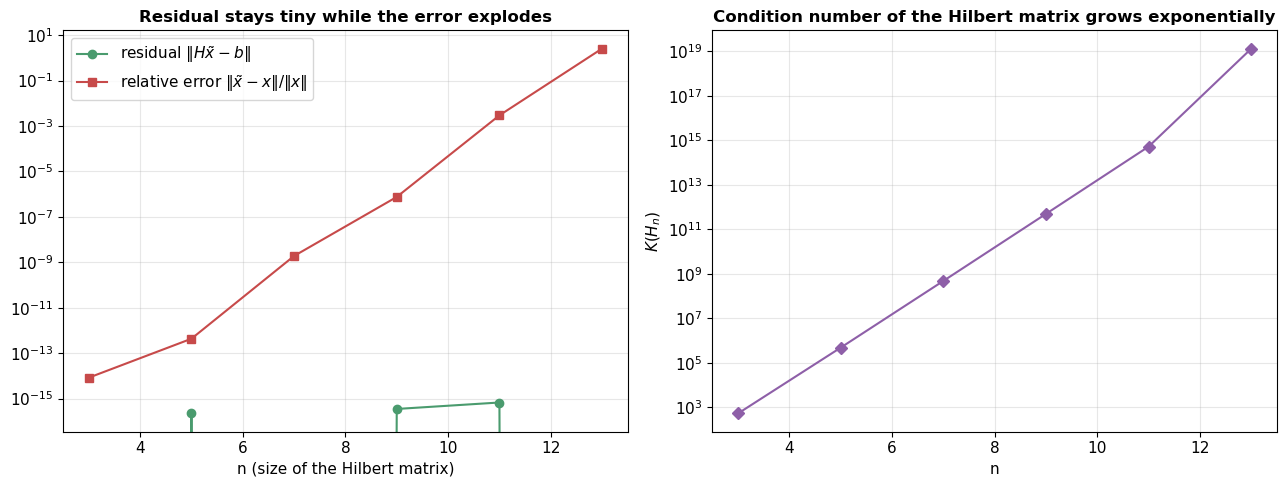

In [17]:

ns_arr = np.array([r[0] for r in rows])
res_arr = np.array([r[1] for r in rows])
err_arr = np.array([r[2] for r in rows])
cond_arr = np.array([r[3] for r in rows])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(ns_arr, res_arr, "o-", color=COLORS["green"], label=r"residual $\|H\tilde x - b\|$")
ax.semilogy(ns_arr, err_arr, "s-", color=COLORS["red"],   label=r"relative error $\|\tilde x - x\|/\|x\|$")
ax.set_xlabel("n (size of the Hilbert matrix)")
ax.set_title("Residual stays tiny while the error explodes")
ax.legend()

ax = axes[1]
ax.semilogy(ns_arr, cond_arr, "D-", color=COLORS["purple"])
ax.set_xlabel("n")
ax.set_ylabel(r"$K(H_n)$")
ax.set_title("Condition number of the Hilbert matrix grows exponentially")

plt.tight_layout()
plt.show()


**This is the punchline of Section 4.** The residual — the only thing an algorithm can check
without knowing the true answer — says almost nothing when $K(A)$ is large: it can be at machine
precision while the computed solution is off by orders of magnitude. *"Well-conditioned inputs"* like
symmetric positive-definiteness give **no** guarantee of a well-conditioned problem.

## 4.4 A geometric picture of ill-conditioning

Recall from Section 2.5: a matrix maps the unit circle to an ellipse. The **eccentricity** of that
ellipse is a direct visualization of the condition number: a well-conditioned matrix produces a
near-circular ellipse (all directions are stretched about equally); an ill-conditioned matrix
produces a needle-thin ellipse (one direction is stretched enormously more than another).


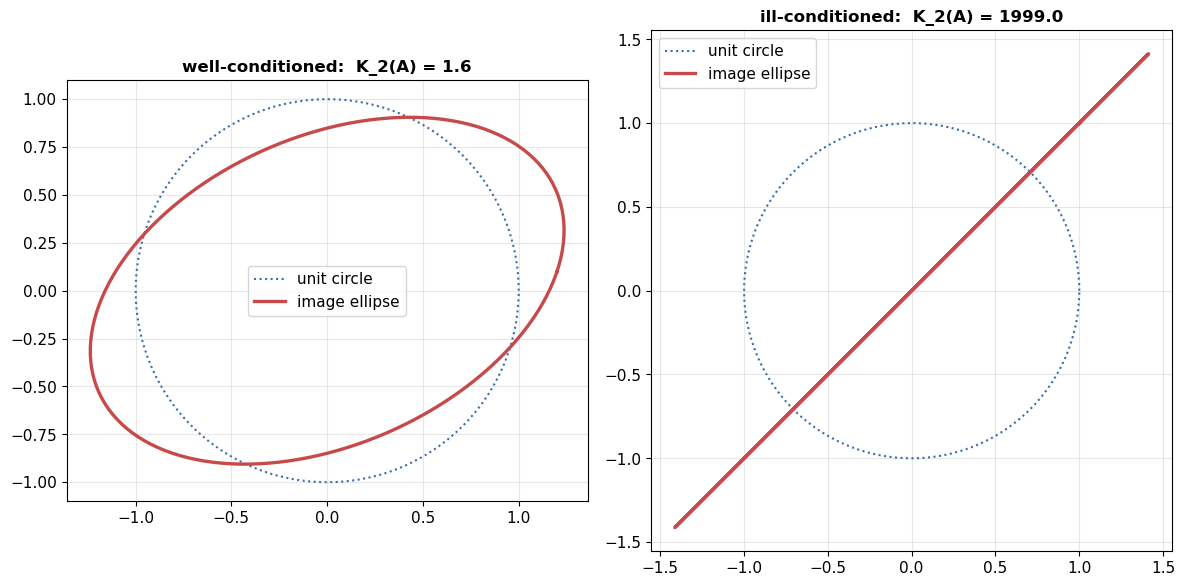

In [18]:

def unit_circle(n=300):
    t = np.linspace(0, 2*np.pi, n)
    return np.vstack([np.cos(t), np.sin(t)])

A_good = np.array([[1.2, 0.3], [0.1, 0.9]])       # well conditioned
A_bad  = np.array([[1.0, 0.999], [0.999, 1.0]])   # nearly singular -> ill conditioned

circ = unit_circle()
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, A, name in zip(axes, [A_good, A_bad], ["well-conditioned", "ill-conditioned"]):
    img = A @ circ
    ax.plot(*circ, color=COLORS["blue"], lw=1.5, ls=":", label="unit circle")
    ax.plot(*img, color=COLORS["red"], lw=2.4, label="image ellipse")
    ax.set_aspect("equal"); ax.legend()
    ax.set_title(f"{name}:  K_2(A) = {np.linalg.cond(A):.1f}")
plt.tight_layout()
plt.show()


The needle-thin ellipse on the right is not just a picture — it *is* the condition number: we
will prove in Section 6 that $K_2(A) = \sigma_1/\sigma_k$, the ratio between the ellipse's longest and
shortest semi-axes. A matrix that is "almost" not invertible (almost collapses the plane onto a
line) has $K(A)\to\infty$, and that is precisely the geometric statement that the ellipse degenerates
into a segment.


---
# 5. Eigenvalues and eigenvectors

## 5.1 Definition and diagonalization

$\lambda \in \mathbb{C}$, $x\in\mathbb{C}^n\setminus\{0\}$ are an **eigenvalue/eigenvector** pair of
$A$ if $Ax=\lambda x$, i.e. $(A-\lambda I)x=0$ — so $A-\lambda I$ is singular and
$\det(A-\lambda I)=0$. The eigenvalues are exactly the $n$ roots (in $\mathbb{C}$, counted with
multiplicity) of the **characteristic polynomial** $p_n(\lambda)=\det(A-\lambda I)$.

If $A$ has $n$ linearly independent eigenvectors $w_1,\dots,w_n$ (collected as columns of $X$), then
$$ AX = X\Lambda \quad\Longrightarrow\quad A = X\Lambda X^{-1}, \qquad \Lambda=\mathrm{diag}(\lambda_1,\dots,\lambda_n). $$
This is a **factorization** of $A$ — but, unlike the SVD we build in Section 6, it does **not**
always exist: it requires $X$ to be invertible, and not every matrix has enough independent
eigenvectors.

Two useful properties we will reuse:
* **Similar matrices** ($A=CBC^{-1}$) share the same eigenvalues.
* If $A$ is invertible with eigenpair $(\lambda,x)$, then $A^{-1}$ has the **same eigenvector** $x$
  with eigenvalue $1/\lambda$.

## 5.2 Symmetric matrices: the well-behaved case

**Spectral theorem.** If $A=A^T$, then (i) all eigenvalues are real, (ii) eigenvectors for distinct
eigenvalues are orthogonal, and (iii) $A$ is diagonalizable by an **orthogonal** matrix:
$$ A = Q\Lambda Q^T, \qquad Q^TQ=I. $$
Because $K_2(Q)=1$ for orthogonal $Q$, diagonalizing a symmetric matrix is an intrinsically
well-conditioned operation — one reason symmetric eigenproblems are numerically "easy" while general
ones are not.


In [19]:

rng = np.random.default_rng(3)
M = rng.normal(size=(5, 5))
A_sym = (M + M.T) / 2   # any matrix symmetrized

eigvals, Q = np.linalg.eigh(A_sym)   # eigh exploits + guarantees symmetry
print("Eigenvalues (all real):", eigvals)
print("\nQ^T Q  (should be I):\n", Q.T @ Q)
print("\n||A - Q Lambda Q^T|| =", np.linalg.norm(A_sym - Q @ np.diag(eigvals) @ Q.T))

# ||A||_2 for a symmetric matrix = max |eigenvalue| -- a preview of Section 6
print("\n||A||_2 (numpy)                =", np.linalg.norm(A_sym, 2))
print("max |eigenvalue(A)| (formula)  =", np.max(np.abs(eigvals)))


Eigenvalues (all real): [-3.8849 -0.5456  0.4507  1.5169  2.9776]

Q^T Q  (should be I):
 [[ 1. -0. -0. -0. -0.]
 [-0.  1. -0.  0.  0.]
 [-0. -0.  1. -0.  0.]
 [-0.  0. -0.  1.  0.]
 [-0.  0.  0.  0.  1.]]

||A - Q Lambda Q^T|| = 5.366165684779049e-15

||A||_2 (numpy)                = 3.884943231998856
max |eigenvalue(A)| (formula)  = 3.8849432319988546


## 5.3 When diagonalization fails: a defective matrix and eigenvalue sensitivity

Not every matrix is diagonalizable. The classic counter-example is a **Jordan block**:
$$ A = \begin{bmatrix}2&1&0\\0&2&1\\0&0&2\end{bmatrix}. $$
$A$ has a single eigenvalue $\lambda=2$ with algebraic multiplicity 3, but only **one** linearly
independent eigenvector — $A$ cannot be diagonalized. Even worse: for matrices *close* to being
defective like this one, eigenvalues can be **extraordinarily sensitive** to tiny perturbations of
the matrix entries — a striking illustration of "numerical arithmetic behaves differently than we
expect". Take an $n\times n$ Jordan block with eigenvalue $\lambda$ and perturb a single corner entry
by $\epsilon$: the eigenvalues of the perturbed matrix move by an amount of order
$\epsilon^{1/n}$ — for $n=8$ and $\epsilon=10^{-8}$, that is a shift of order $10^{-1}$, i.e. a
perturbation *smaller than machine epsilon in relative terms* produces eigenvalues that visibly
move away from $\lambda$.


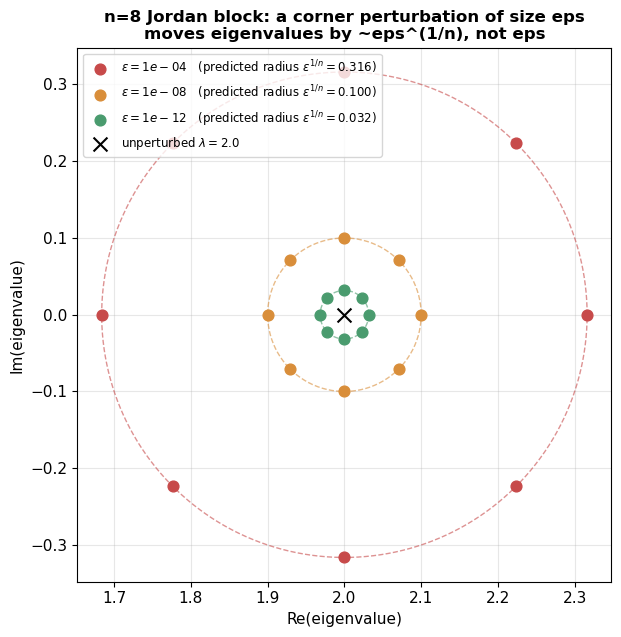

Unperturbed eigenvalues (exact Jordan block): [2. 2. 2. 2. 2. 2. 2. 2.]


In [20]:

n = 8
lam = 2.0
eps_list = [1e-4, 1e-8, 1e-12]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
theta = np.linspace(0, 2*np.pi, 200)

colors_eps = [COLORS["red"], COLORS["orange"], COLORS["green"]]
for eps, col in zip(eps_list, colors_eps):
    J = np.diag(lam*np.ones(n)) + np.diag(np.ones(n-1), 1)
    J[-1, 0] += eps                      # a single tiny corner perturbation
    ev = np.linalg.eigvals(J)
    ax.scatter(ev.real, ev.imag, color=col, s=60, zorder=3,
               label=fr"$\epsilon={eps:.0e}$   (predicted radius $\epsilon^{{1/n}}={eps**(1/n):.3f}$)")
    ax.plot(lam + eps**(1/n)*np.cos(theta), eps**(1/n)*np.sin(theta),
            color=col, lw=1, ls="--", alpha=0.6)

ax.scatter([lam], [0], color="black", marker="x", s=100, zorder=4, label=fr"unperturbed $\lambda={lam}$")
ax.set_aspect("equal")
ax.set_xlabel("Re(eigenvalue)"); ax.set_ylabel("Im(eigenvalue)")
ax.set_title(f"n={n} Jordan block: a corner perturbation of size eps\nmoves eigenvalues by ~eps^(1/n), not eps")
ax.legend(fontsize=8.5, loc="upper left")
plt.tight_layout()
plt.show()

print("Unperturbed eigenvalues (exact Jordan block):", np.linalg.eigvals(np.diag(lam*np.ones(n)) + np.diag(np.ones(n-1),1)))


A perturbation of size $10^{-12}$ in a single matrix entry — far below anything visible in a
printed matrix, and comparable to *rounding error itself* — moves the eigenvalues off $\lambda=2$
onto a circle of radius $\approx (10^{-12})^{1/8}\approx 10^{-1.5}\approx 0.03$. **The eigenvalue
problem for a non-symmetric, nearly-defective matrix can be badly ill-conditioned even when $A$
itself looks perfectly innocuous** — a cautionary tale that motivates why, for general matrices, we
will prefer the SVD (Section 6), whose singular values never suffer from this kind of blow-up
(the perturbation of a singular value is bounded by the perturbation of $A$ itself, in any norm —
a fact you can find in Trefethen & Bau, *Numerical Linear Algebra*, Lecture 5).

## 5.4 Eigenvectors vs. the ellipse: they don't always line up

Return to the unit-circle-to-ellipse picture (Section 2.5). For a symmetric matrix, the
eigenvector directions *are* the axes of the ellipse (by the spectral theorem). For a
**non-symmetric** matrix, this breaks: the eigenvectors need not even be orthogonal, so they cannot
in general point along the ellipse's axes.


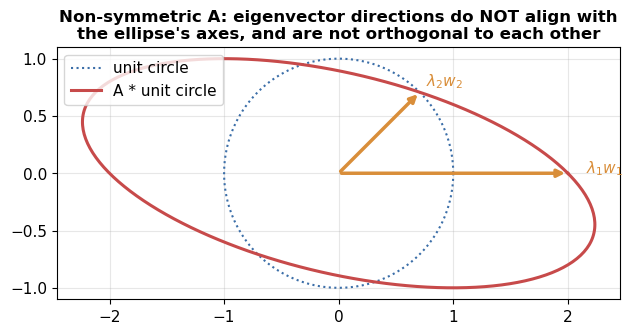

Eigenvectors:
 [[1.     0.7071]
 [0.     0.7071]]

Angle between the two eigenvectors: 45.00000000000001 degrees  (90 deg would mean orthogonal)


In [21]:

def unit_circle(n=300):
    t = np.linspace(0, 2*np.pi, n)
    return np.vstack([np.cos(t), np.sin(t)])

A_ns = np.array([[2.0, -1.0],
                  [0.0,  1.0]])   # upper triangular, non-symmetric, eigenvalues 2 and 1
eigvals, eigvecs = np.linalg.eig(A_ns)
circ = unit_circle()
img = A_ns @ circ

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(*circ, color=COLORS["blue"], lw=1.5, ls=":", label="unit circle")
ax.plot(*img, color=COLORS["red"], lw=2.2, label="A * unit circle")

for i in range(2):
    v = eigvecs[:, i].real
    ax.annotate("", xy=v*eigvals[i].real, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=COLORS["orange"], lw=2.5))
    ax.text(*(v*eigvals[i].real*1.08), fr"$\lambda_{i+1} w_{i+1}$", color=COLORS["orange"], fontweight="bold")

ax.set_aspect("equal"); ax.legend(loc="upper left")
ax.set_title("Non-symmetric A: eigenvector directions do NOT align with\nthe ellipse's axes, and are not orthogonal to each other")
plt.tight_layout()
plt.show()

print("Eigenvectors:\n", eigvecs)
print("\nAngle between the two eigenvectors:",
      np.degrees(np.arccos(np.clip(eigvecs[:,0] @ eigvecs[:,1], -1, 1))), "degrees  (90 deg would mean orthogonal)")


The eigenvectors are real and the eigenvalues ($2$ and $1$) are the diagonal entries (the
matrix is triangular) — but the two eigenvector directions are **not orthogonal**, and neither one
points along the major axis of the red ellipse. Eigen-decomposition answers the question *"which
directions does $A$ merely rescale?"* — a different question from *"which directions are
stretched the most?"*. The SVD, next, is built to answer the second question, for every matrix.


---
# 6. The Singular Value Decomposition — a factorization for *every* matrix

## 6.1 Motivation

Section 5 diagonalized symmetric matrices beautifully, but hit two walls: not every matrix is
diagonalizable, and even when it is, non-symmetric eigenvectors need not be orthogonal — so
eigen-decomposition cannot, in general, answer "which orthogonal directions does $A$ stretch, and by
how much?" It also says nothing about **rectangular** matrices, which don't even have eigenvalues.

The **SVD** fixes all of this at once. For *every* $A\in\mathbb{R}^{m\times n}$ (square or not,
singular or not, symmetric or not) there exist orthogonal $U\in\mathbb{R}^{m\times m}$,
$V\in\mathbb{R}^{n\times n}$ and diagonal $\Sigma\in\mathbb{R}^{m\times n}$ with
$\sigma_1\ge\sigma_2\ge\cdots\ge 0$ such that
$$ A = U\Sigma V^T. $$

## 6.2 Where it comes from: diagonalizing $A^TA$ and $AA^T$

$A^TA\in\mathbb{R}^{n\times n}$ is always symmetric (and positive semi-definite), so by the spectral
theorem it has an orthogonal eigen-decomposition. Substituting the (assumed) SVD of $A$,
$$ A^TA = (U\Sigma V^T)^T(U\Sigma V^T) = V\Sigma^T U^TU\Sigma V^T = V(\Sigma^T\Sigma)V^T, $$
using $U^TU=I$. So **the columns of $V$ (right singular vectors) are the eigenvectors of $A^TA$**,
and the diagonal of $\Sigma^T\Sigma$ — the eigenvalues of $A^TA$ — equals $\sigma_i^2$. Symmetrically,
$AA^T = U(\Sigma\Sigma^T)U^T$, so **the columns of $U$ (left singular vectors) are the eigenvectors of
$AA^T$**. Because $A^TA$ and $AA^T$ are symmetric, this argument *guarantees* $U$ and $V$ are
orthogonal — for *any* $A$, unconditionally.

## 6.3 Geometry: singular values are the semi-axes of the image ellipse

Exactly the picture from Sections 2 and 5, but now for *every* matrix: the image of the unit
sphere under $A$ is an ellipsoid whose semi-axes are **orthogonal** and have lengths $\sigma_i$,
pointing along $u_i$; their preimages are the orthogonal directions $v_i$. Let's reproduce the
course's own example matrices and check that this always holds — including for the non-symmetric
case where Section 5 showed eigenvectors *failed* to align with the ellipse.


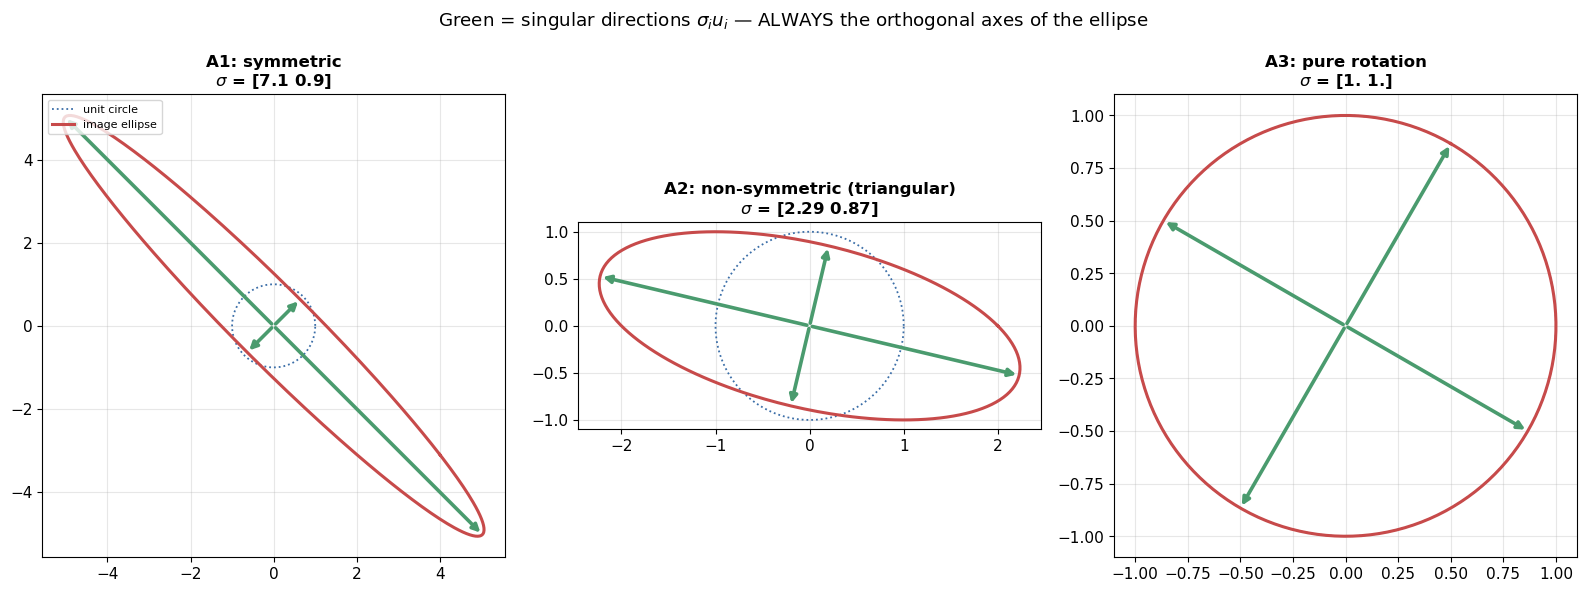

In [22]:

def unit_circle(n=300):
    t = np.linspace(0, 2*np.pi, n)
    return np.vstack([np.cos(t), np.sin(t)])

A1 = np.array([[4.0, -3.1], [-3.1, 4.0]])                                   # symmetric
A2 = np.array([[2.0, -1.0], [0.0, 1.0]])                                    # non-symmetric
A3 = np.array([[np.cos(np.pi/3), -np.sin(np.pi/3)],
               [np.sin(np.pi/3),  np.cos(np.pi/3)]])                        # rotation

circ = unit_circle()
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
titles = ["A1: symmetric", "A2: non-symmetric (triangular)", "A3: pure rotation"]

for ax, A, title in zip(axes, [A1, A2, A3], titles):
    U, S, VT = np.linalg.svd(A)
    img = A @ circ
    ax.plot(*circ, color=COLORS["blue"], lw=1.3, ls=":", label="unit circle")
    ax.plot(*img, color=COLORS["red"], lw=2.2, label="image ellipse")
    for i in range(2):
        axis_vec = S[i] * U[:, i]
        ax.annotate("", xy=axis_vec, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=COLORS["green"], lw=2.6))
        ax.annotate("", xy=-axis_vec, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=COLORS["green"], lw=2.6))
    ax.set_aspect("equal"); ax.set_title(f"{title}\n" + r"$\sigma$ = " + np.array2string(S, precision=2))
    if ax is axes[0]:
        ax.legend(loc="upper left", fontsize=8)
plt.suptitle(r"Green = singular directions $\sigma_i u_i$ — ALWAYS the orthogonal axes of the ellipse", y=1.03)
plt.tight_layout()
plt.show()


Unlike the eigenvector picture in Section 5.4, the singular directions (green) are *always*
orthogonal and *always* line up exactly with the ellipse's axes — for the symmetric matrix, the
non-symmetric one, and even the pure rotation (whose eigenvalues are complex and give no real
picture at all, yet its SVD is perfectly well defined: $\sigma_1=\sigma_2=1$, a rotation does not
stretch anything).

## 6.4 The SVD as a sum of rank-1 pieces

Multiplying a matrix on the right by a diagonal matrix rescales its *columns* (Section 2.4), so
$U\Sigma = [\sigma_1 u_1, \dots, \sigma_n u_n]$, and therefore
$$ A = U\Sigma V^T = \sum_{i=1}^{n} \sigma_i\, u_i v_i^T. $$
Every matrix is a sum of **rank-1 outer products** $u_iv_i^T$, weighted by the singular values —
the natural generalization of the rank-1 matrices from Section 2.4. If $\mathrm{rank}(A)=k$, only
the first $k$ terms are non-zero.


In [23]:

rng = np.random.default_rng(7)
A = rng.integers(-3, 4, size=(4, 3)).astype(float)
U, S, VT = np.linalg.svd(A, full_matrices=False)
V = VT.T
r = np.linalg.matrix_rank(A)

print("A =\n", A, "\n   rank(A) =", r)
print("\nsingular values sigma =", S)

partial = np.zeros_like(A)
for i in range(len(S)):
    term = S[i] * np.outer(U[:, i], V[:, i])
    partial = partial + term
    print(f"\n-- after adding rank-1 term #{i+1} (sigma_{i+1}={S[i]:.4f}) --")
    print("partial sum =\n", np.round(partial, 4))
    print("||A - partial sum||_F =", np.linalg.norm(A - partial))


A =
 [[ 3.  1.  1.]
 [ 3.  1.  2.]
 [ 2. -2. -3.]
 [-1. -2.  3.]] 
   rank(A) = 3

singular values sigma = [4.97   4.7958 2.8809]

-- after adding rank-1 term #1 (sigma_1=4.9700) --
partial sum =
 [[ 2.395   1.0183  1.7963]
 [ 2.8253  1.2012  2.1189]
 [-0.6312 -0.2683 -0.4734]
 [ 0.2293  0.0975  0.172 ]]
||A - partial sum||_F = 5.594585799375288

-- after adding rank-1 term #2 (sigma_2=4.7958) --
partial sum =
 [[ 2.995   1.0183  0.9963]
 [ 2.9453  1.2012  1.9589]
 [ 1.5288 -0.2683 -3.3534]
 [-1.5707  0.0975  2.572 ]]
||A - partial sum||_F = 2.8808662354527392

-- after adding rank-1 term #3 (sigma_3=2.8809) --
partial sum =
 [[ 3.  1.  1.]
 [ 3.  1.  2.]
 [ 2. -2. -3.]
 [-1. -2.  3.]]
||A - partial sum||_F = 3.688882027804963e-15


The residual norm hits (numerical) zero exactly at the $r$-th term, confirming
$A=\sum_{i=1}^{r}\sigma_i u_iv_i^T$ with $r=\mathrm{rank}(A)$: **the SVD literally builds $A$ up, one
rank-1 layer at a time, from most to least important.**

## 6.5 Application: image compression by low-rank approximation

Treat a grayscale image as a matrix of pixel intensities. The rank-1 sum above says we can
reconstruct the image using only the first $r$ terms:
$$ A_r = \sum_{i=1}^{r}\sigma_i u_i v_i^T, \qquad
   \lVert A-A_r\rVert_2=\sigma_{r+1}. $$
Storing $A_r$ costs $r(m+n+1)$ numbers instead of $mn$ — a genuine compression whenever
$r\ll \min(m,n)$. As a test image we use a real photograph — Matteo and his dog Numa — instead of
a synthetic pattern: a real picture mixes smooth, low-detail regions (the grass background, the
soft shading of the fur) with sharp, high-frequency detail (the dog's eyes, the boy's face, the
texture of the fur), which is exactly the mix that makes singular-value decay interesting.


Image shape: (1024, 1024)   dtype range: [ 0.0 , 254.0 ]


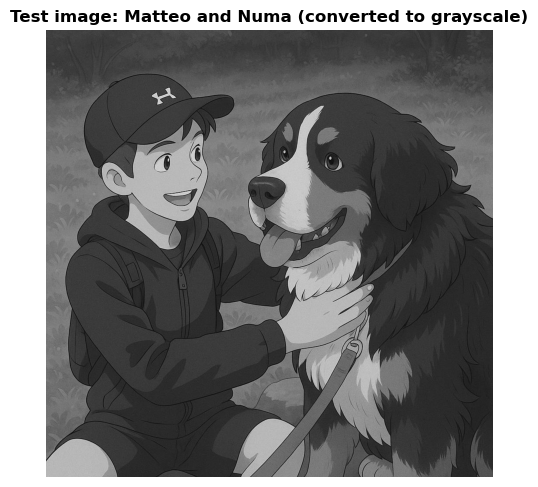

In [24]:

IMG_PATH = "Matteo e numa.jpg"   # place this notebook and the photo in the same folder
IMG = np.asarray(Image.open(IMG_PATH).convert("L"), dtype=np.float64)
print("Image shape:", IMG.shape, "  dtype range: [", IMG.min(), ",", IMG.max(), "]")

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(IMG, cmap="gray", vmin=0, vmax=255)
ax.set_title("Test image: Matteo and Numa (converted to grayscale)")
ax.axis("off")
plt.tight_layout()
plt.show()


Image is 1024x1024;  1024 singular values;  sigma_1=88045.0,  sigma_last=0.0124


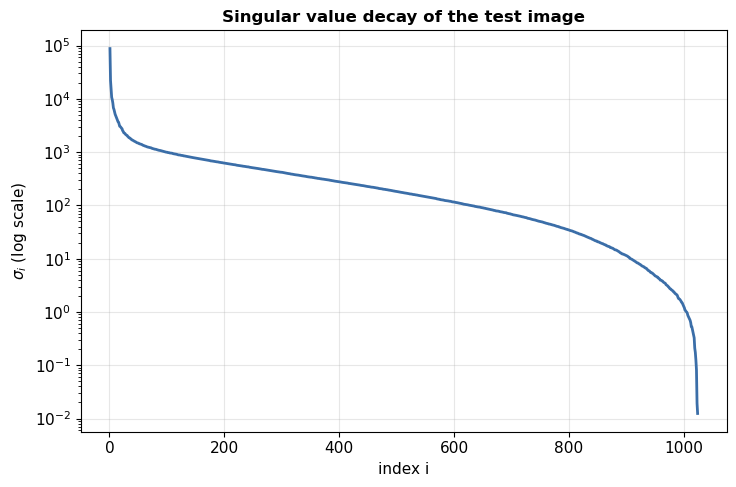

In [25]:

U, S, VT = np.linalg.svd(IMG, full_matrices=False)
m, n = IMG.shape
full_rank = len(S)
print(f"Image is {m}x{n};  {full_rank} singular values;  sigma_1={S[0]:.1f},  sigma_last={S[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.semilogy(np.arange(1, full_rank+1), S, color=COLORS["blue"], lw=2)
ax.set_xlabel("index i"); ax.set_ylabel(r"$\sigma_i$ (log scale)")
ax.set_title("Singular value decay of the test image")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


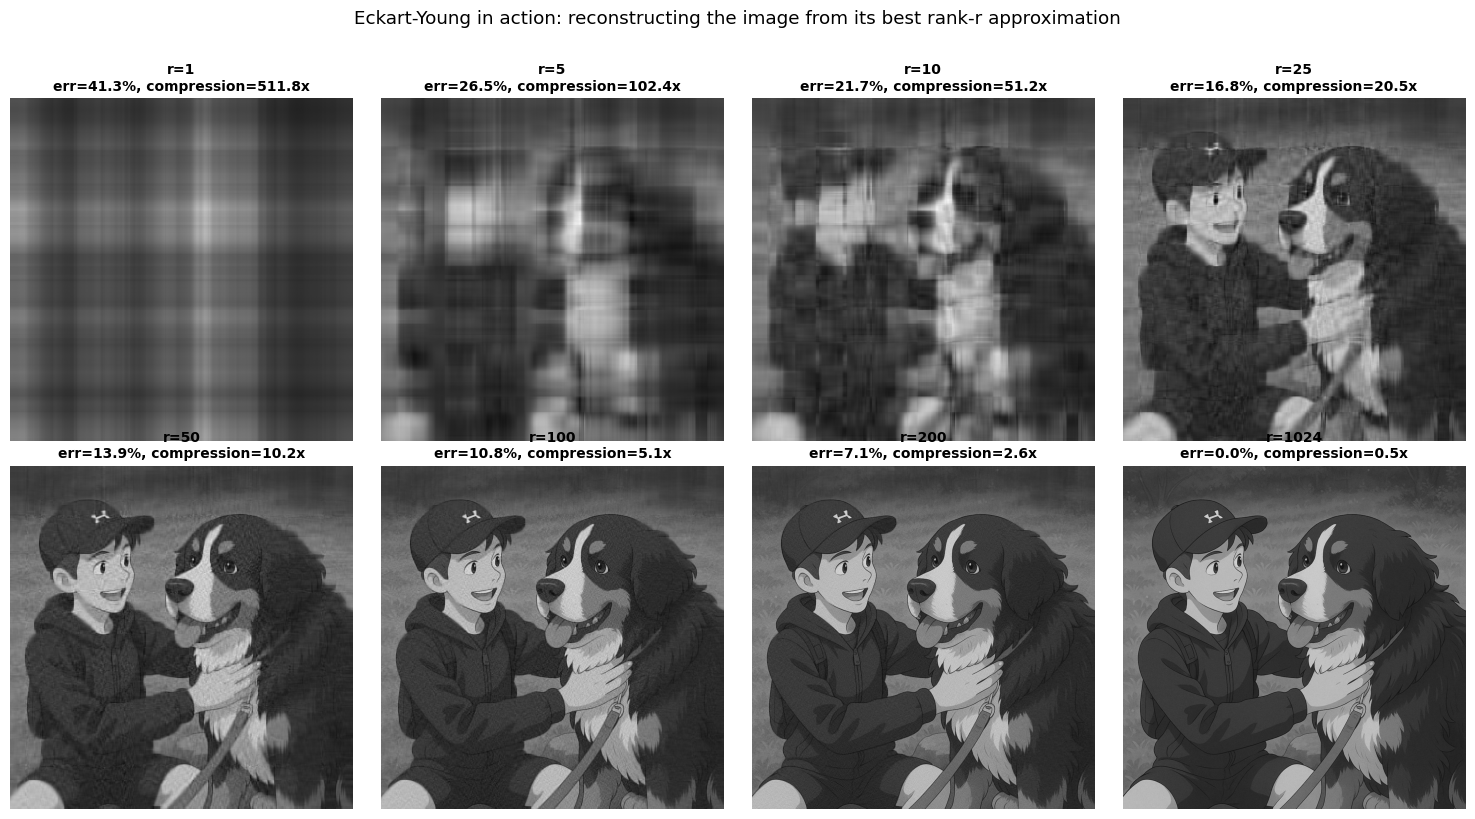

In [26]:

def low_rank_image(U, S, VT, r):
    return (U[:, :r] * S[:r]) @ VT[:r, :]

ranks_to_show = [1, 5, 10, 25, 50, 100, 200, full_rank]
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

for ax, r in zip(axes.ravel(), ranks_to_show):
    Ar = low_rank_image(U, S, VT, r)
    rel_err = np.linalg.norm(IMG - Ar, "fro") / np.linalg.norm(IMG, "fro")
    storage = r * (m + n + 1)
    ratio = (m*n) / storage
    ax.imshow(np.clip(Ar, 0, 255), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"r={r}\nerr={rel_err:.1%}, compression={ratio:.1f}x", fontsize=10)
    ax.axis("off")

plt.suptitle("Eckart-Young in action: reconstructing the image from its best rank-r approximation", y=1.02)
plt.tight_layout()
plt.show()


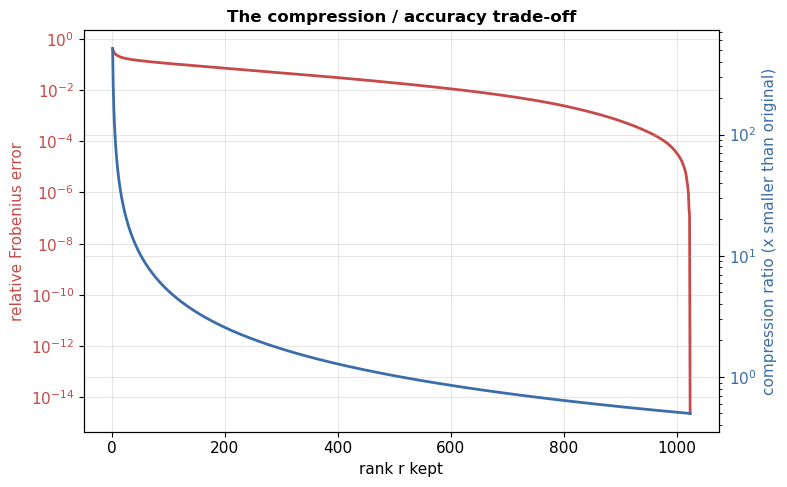

||A - A_15||_2 (numerically)  = 3658.2233805543055
sigma_16 (theory: should match exactly) = 3658.2233805543


In [27]:

ranks = np.arange(1, full_rank+1)
rel_errors = []
ratios = []
for r in ranks:
    Ar = low_rank_image(U, S, VT, r)
    rel_errors.append(np.linalg.norm(IMG - Ar, "fro") / np.linalg.norm(IMG, "fro"))
    ratios.append((m*n) / (r*(m+n+1)))

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(ranks, rel_errors, color=COLORS["red"], lw=2)
ax1.set_xlabel("rank r kept")
ax1.set_ylabel("relative Frobenius error", color=COLORS["red"])
ax1.tick_params(axis="y", labelcolor=COLORS["red"])
ax1.set_yscale("log")

ax2 = ax1.twinx()
ax2.plot(ranks, ratios, color=COLORS["blue"], lw=2)
ax2.set_ylabel("compression ratio (x smaller than original)", color=COLORS["blue"])
ax2.tick_params(axis="y", labelcolor=COLORS["blue"])
ax2.set_yscale("log")

ax1.set_title("The compression / accuracy trade-off")
plt.tight_layout()
plt.show()

# Eckart-Young theorem, checked numerically:
r_check = 15
Ar = low_rank_image(U, S, VT, r_check)
print(f"||A - A_{r_check}||_2 (numerically)  =", np.linalg.norm(IMG - Ar, 2))
print(f"sigma_{r_check+1} (theory: should match exactly) =", S[r_check])


**Reading the trade-off curve.** The error drops steeply for the first few dozen singular
values — that is the smooth grass background and the broad shading of boy and dog, which a real
photograph represents almost as compactly as a synthetic low-rank pattern would — and then
flattens into a long, slowly-decaying tail, which is the price of representing fine detail: the
dog's fur texture, the boy's facial features, the sharp edge of the cap. This is *exactly* the
singular-value decay plot from two cells above, just read as an error curve instead. **The
Eckart–Young theorem guarantees this greedy, rank-1-at-a-time reconstruction is
not just a good approximation — it is the provably best possible rank-$r$ approximation to $A$ in
the 2-norm, among *all* rank-$r$ matrices**, with error exactly $\sigma_{r+1}$ — confirmed above to
machine precision.

## 6.6 The pseudo-inverse, and the condition number, for *any* matrix

For a square invertible $A=U\Sigma V^T$, $A^{-1}=V\Sigma^{-1}U^T$. This generalizes to *any*
$A\in\mathbb{R}^{m\times n}$ of rank $k$ via the **Moore–Penrose pseudo-inverse**
$$ A^{\dagger} = V\Sigma^{\dagger}U^T, \qquad
   \Sigma^{\dagger} = \mathrm{diag}\Big(\tfrac1{\sigma_1},\dots,\tfrac1{\sigma_k},0,\dots,0\Big), $$
which satisfies $AA^{\dagger}A=A$ and reduces to the ordinary inverse whenever $A$ is square and
invertible. With it, the **condition number generalizes to every matrix**, symmetric or not,
square or not:
$$ K_2(A) = \lVert A\rVert_2\,\lVert A^{\dagger}\rVert_2 = \frac{\sigma_1}{\sigma_k}. $$


In [28]:

A_rect = np.array([[1.0, 2.0], [3.0, 4.0], [5.0, 6.1]])   # 3x2, full column rank
U, S, VT = np.linalg.svd(A_rect, full_matrices=False)
pinv_svd = (VT.T * (1/S)) @ U.T
pinv_numpy = np.linalg.pinv(A_rect)

print("Pseudo-inverse via SVD:\n", pinv_svd)
print("\nnp.linalg.pinv:\n", pinv_numpy)
print("\nMatch:", np.allclose(pinv_svd, pinv_numpy))
print("\nA^+ A =\n", np.round(pinv_svd @ A_rect, 6), " (left-inverse: I, since A has full column rank)")

K2_svd = S[0] / S[-1]
print("\nK2(A) = sigma_1/sigma_k =", K2_svd, "   np.linalg.cond(A) =", np.linalg.cond(A_rect))


Pseudo-inverse via SVD:
 [[-1.4385 -0.2882  0.6606]
 [ 1.1538  0.2941 -0.4072]]

np.linalg.pinv:
 [[-1.4385 -0.2882  0.6606]
 [ 1.1538  0.2941 -0.4072]]

Match: True

A^+ A =
 [[ 1. -0.]
 [ 0.  1.]]  (left-inverse: I, since A has full column rank)

K2(A) = sigma_1/sigma_k = 19.56359436108115    np.linalg.cond(A) = 19.563594361081147


## 6.7 Closing the loop: SVD, condition number, and near rank-deficiency

We can now say precisely what an ill-conditioned matrix *is*, in every sense used in this notebook:

* **Section 4** showed a needle-thin image ellipse means large $K(A)$.
* **Section 6.2–6.3** showed the ellipse's semi-axes *are* the singular values $\sigma_i$.
* Therefore $K_2(A)=\sigma_1/\sigma_k$: a large condition number means the *smallest* singular value
  is tiny compared to the largest — i.e. $A$ is *almost* rank-deficient, almost collapsing some
  direction to zero.

This is why the SVD is the computational tool of choice whenever conditioning matters: it exposes,
directly and for any matrix, exactly how close $A$ is to being singular, and along *which* direction
the danger lies (the singular vector $v_k$ associated with $\sigma_k$). When $K(A)$ is large, adding
a small amount of regularization or working in extended precision — informed by exactly this
picture — is the standard remedy.


---
# 7. Wrap-up

## 7.1 Summary table

| # | Pillar | Key formula | Key code |
|---|---|---|---|
| 1 | Floating point | $\varepsilon=\tfrac12\beta^{1-t}$, relative error $\le\varepsilon$ | `np.finfo(dtype).eps` |
| 2 | Linear systems | $Ax=x_1a_1+\dots+x_na_n$; rank/kernel/range | `np.linalg.matrix_rank`, `np.linalg.solve` |
| 3 | Norms | $\lVert A\rVert_p=\sup_{\lVert x\rVert_p=1}\lVert Ax\rVert_p$ | `np.linalg.norm(A, ord=...)` |
| 4 | Condition number | $K(A)=\lVert A\rVert\lVert A^{-1}\rVert\ge 1$ | `np.linalg.cond(A)` |
| 5 | Eigenvalues | $Ax=\lambda x$; symmetric $\Rightarrow A=Q\Lambda Q^T$ | `np.linalg.eig` / `eigh` |
| 6 | SVD | $A=U\Sigma V^T=\sum_i\sigma_i u_iv_i^T$; $K_2(A)=\sigma_1/\sigma_k$ | `np.linalg.svd` |

## 7.2 Exercises

Adapted from the *dispensa*, §1.8 — try them in a fresh cell below.

1. **Condition number growth.** Let $A_k$ be the $3\times3$ tridiagonal matrix with $k$ on the main
   diagonal and $-1$ on the two adjacent diagonals. Compute $K_2(A_k)$ for a range of $k$. What
   happens as $k\to\infty$? For which $k$ does $A_k$ become singular?
2. **Vectorization speed-up.** For a random $n\times n$ matrix, time the computation of $A^TA$ (a)
   with three nested `for` loops and (b) as `A.T @ A`. Plot both timings vs. $n$ on a log-log scale.
   How do the asymptotic slopes compare to the $O(n^3)$ operation count derived in Section 2?
3. **Your own image.** Load a different photograph via `PIL.Image.open(...).convert("L")`.
   Recompute the singular value decay and the rank-accuracy trade-off curve — how does its
   singular-value decay compare to the photograph used above?
4. **Pseudo-inverse properties.** Prove numerically (for a random rectangular $A$) that the
   Moore–Penrose pseudo-inverse from §6.6 satisfies all four defining identities
   $AA^{\dagger}A=A$, $A^{\dagger}AA^{\dagger}=A^{\dagger}$, $(AA^{\dagger})^T=AA^{\dagger}$,
   $(A^{\dagger}A)^T=A^{\dagger}A$.

## 7.3 References

**Course material**

* G. Puppo, *Metodi Numerici* (lecture notes), Sapienza Università di Roma — Chapter 1,
  *Strumenti del mestiere*.
* Lecture notes L1–L7 (2026): *Numeri macchina*, *Ripasso Matrici*, *Sistemi Lineari*, *Norma*,
  *Autovalori e Autovettori*, *SVD parte 1–2*.
* Course concept map, *Mappa concettuale — Cap. 1*.

**Textbooks**

* A. Greenbaum, T. P. Chartier, *Numerical Methods: Design, Analysis, and Computer Implementation of
  Algorithms*, Princeton University Press, 2012.
* A. Quarteroni, R. Sacco, F. Saleri, P. Gervasio, *Matematica Numerica*, Springer, 2014.
* L. N. Trefethen, D. Bau III, *Numerical Linear Algebra*, SIAM, 1997. *(existence/uniqueness of the
  SVD, Eckart–Young theorem, singular-value perturbation bounds)*
* G. Golub, C. Van Loan, *Matrix Computations*, The Johns Hopkins University Press, 1996.
* A. Greenbaum, *Iterative Methods for Solving Linear Systems*, SIAM, 1997.
* M. P. Deisenroth, A. A. Faisal, C. S. Ong, *Mathematics for Machine Learning*, Cambridge University
  Press, 2020. *(SVD applications: PCA, compression)*

---
*End of Chapter 1. Next: Chapter 2 — linear systems (Gauss elimination, LU factorization, iterative
methods).*
